Synthetic test explainer 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


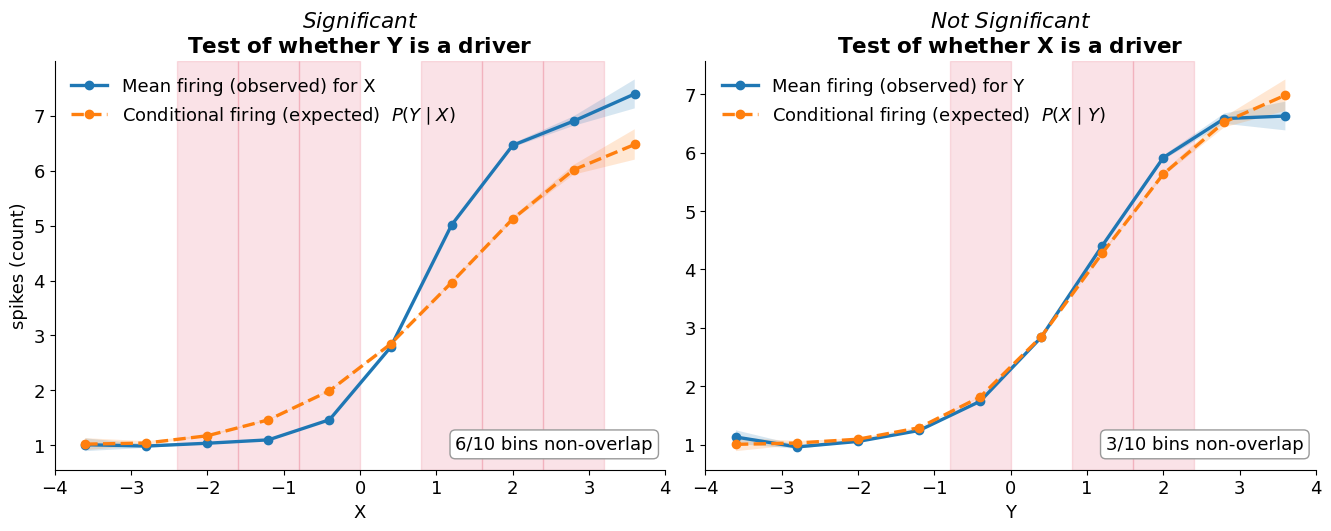

In [1]:
"""
Disentangling tuning to two correlated variables (linear, publication-ready).

Left: test whether Y drives X  -> compare TF_X vs E[TF_Y|X] using P(Y|X)  -> usually Significant
Right: test whether X drives Y -> compare TF_Y vs E[TF_X|Y] using P(X|Y)  -> usually Not Significant

Enhancements:
- Visual per-bin significance: translucent vertical bands where 95% CIs do NOT overlap (Bonferroni).
- Annotate conditionals (P(Y|X) / P(X|Y)) in each subplot.
- Higher Poisson rates and y-label "spikes (count)".
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 120_000
Nbins = 10

# Correlated linear stimuli: X ~ N(0,1), Y = rho*X + sqrt(1-rho^2)*eps
rho = 0.85
X = rng.normal(0.0, 1.0, Nsamples)
eps = rng.normal(0.0, 1.0, Nsamples)
Y = rho * X + np.sqrt(1 - rho**2) * eps

# Poisson spiking truly tuned to X (steep nonlinearity -> separation)
def sigmoid(z): return 1 / (1 + np.exp(-z))
# Higher rates for clearer "spikes (count)" display
baseline = 1.0
amp = 6.0
theta = 0.8
rate = baseline + amp * sigmoid(2.2 * (X - theta))   # mean spikes per sample
rate = np.clip(rate, 0, None)
spikes = rng.poisson(rate)

# ------------------------------- Helpers -------------------------------------
def make_edges(nbins, lo=-4.0, hi=4.0):
    return np.linspace(lo, hi, nbins + 1)

def digitize(x, edges):
    idx = np.digitize(x, edges, right=False) - 1
    return np.clip(idx, 0, len(edges) - 2)

def tuning(spikes, idx, nbins):
    """Mean, SEM, SD, N per bin (robust for N<=1)."""
    mean = np.zeros(nbins, float)
    sem  = np.zeros(nbins, float)
    sd   = np.zeros(nbins, float)
    n    = np.zeros(nbins, int)
    for b in range(nbins):
        m = (idx == b)
        n[b] = int(m.sum())
        if n[b] > 0:
            vals = spikes[m].astype(float)
            mean[b] = vals.mean()
            if n[b] > 1:
                sd[b]  = vals.std(ddof=1)
                sem[b] = sd[b] / np.sqrt(n[b])
            else:
                sd[b] = 0.0
                sem[b] = np.nan
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
            sd[b]   = 0.0
    return mean, sem, sd, n

def counts_matrix(x, y, edges_x, edges_y):
    """Counts C[y_bin, x_bin] (rows=y, cols=x)."""
    H, xedges, yedges = np.histogram2d(x, y, bins=[edges_x, edges_y], density=False)
    return H.T

def conditional_from_counts(C):
    """P(y|x) and P(x|y) from counts C[y, x]."""
    eps = 1e-12
    colsum = C.sum(axis=0, keepdims=True) + eps
    rowsum = C.sum(axis=1, keepdims=True) + eps
    P_y_given_x = C / colsum                  # (Nbins_y, Nbins_x)
    P_x_given_y = (C / rowsum).T              # (Nbins_x, Nbins_y)
    return P_y_given_x, P_x_given_y

def expected_tf(tf_y, P_y_given_x):
    """E[tf_y | x], tf_y: (Nbins_y,), P_y_given_x: (Nbins_y, Nbins_x)."""
    return (tf_y[:, None] * P_y_given_x).sum(axis=0)

def expected_sem_from_second_moment(mean_y, sd_y, n_x, P_y_given_x):
    """Propagate second moment for expected SEM under the null."""
    s2_y = (sd_y**2) + (mean_y**2)
    E_mean = (mean_y[:, None] * P_y_given_x).sum(axis=0)
    E_s2   = (s2_y[:, None]   * P_y_given_x).sum(axis=0)
    var_x  = np.maximum(E_s2 - E_mean**2, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem_x = np.sqrt(var_x / np.maximum(n_x, 1))
    sem_x[n_x <= 1] = np.nan
    return sem_x

def ci_no_overlap(m1, s1, m2, s2, alpha=0.05):
    """Binwise Bonferroni-adjusted CI non-overlap."""
    valid = ~(np.isnan(m1) | np.isnan(s1) | np.isnan(m2) | np.isnan(s2))
    k = max(int(valid.sum()), 1)
    z = norm.ppf(1 - (alpha / k) / 2)
    lo1, hi1 = m1 - z * s1, m1 + z * s1
    lo2, hi2 = m2 - z * s2, m2 + z * s2
    out = (hi1 < lo2) | (lo1 > hi2)
    out[~valid] = False
    return out

def draw_sig_bands(ax, edges, sig_mask, color="crimson", alpha=0.10, zorder=0):
    """Translucent vertical bands for bins where sig_mask is True."""
    for b, sig in enumerate(sig_mask):
        if sig:
            ax.axvspan(edges[b], edges[b+1], color=color, alpha=alpha, zorder=zorder)

# ------------------------- Bin, TFs, conditionals ----------------------------
edges = make_edges(Nbins, lo=-4.0, hi=4.0)
centres = 0.5 * (edges[:-1] + edges[1:])

idxX = digitize(X, edges)
idxY = digitize(Y, edges)

# Observed TFs
mean_X, sem_X, sd_X, n_X = tuning(spikes, idxX, Nbins)   # TF vs X
mean_Y, sem_Y, sd_Y, n_Y = tuning(spikes, idxY, Nbins)   # TF vs Y

# Conditionals from counts
C = counts_matrix(X, Y, edges, edges)       # C[y, x]
P_y_given_x, P_x_given_y = conditional_from_counts(C)

# Expected (null) curves and SEMs
# Left panel: NH "Y drives X" -> use P(Y|X)
exp_X_from_Y = expected_tf(mean_Y, P_y_given_x)
sem_exp_X    = expected_sem_from_second_moment(mean_Y, sd_Y, n_X, P_y_given_x)

# Right panel: NH "X drives Y" -> use P(X|Y)
exp_Y_from_X = expected_tf(mean_X, P_x_given_y)
sem_exp_Y    = expected_sem_from_second_moment(mean_X, sd_X, n_Y, P_x_given_y)

# Significance masks
sig_left  = ci_no_overlap(mean_X, sem_X, exp_X_from_Y, sem_exp_X)
sig_right = ci_no_overlap(mean_Y, sem_Y, exp_Y_from_X, sem_exp_Y)
k_left, k_right = int(sig_left.sum()), int(sig_right.sum())

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=False, constrained_layout=True)

# ----- Left: Test whether Y is a driver (compare TF_X vs E[TF_Y|X], uses P(Y|X)) -----
draw_sig_bands(axL, edges, sig_left, color="crimson", alpha=0.12, zorder=0)

axL.plot(centres, mean_X, "-o", lw=2.4, label="Mean firing (observed) for X")
axL.fill_between(centres, mean_X - sem_X, mean_X + sem_X, alpha=0.18)

axL.plot(centres, exp_X_from_Y, "--o", lw=2.4,
         label=r"Conditional firing (expected)  $P(Y\mid X)$")
axL.fill_between(centres, exp_X_from_Y - sem_exp_X, exp_X_from_Y + sem_exp_X, alpha=0.18)

axL.set_xlim(edges[0], edges[-1])
axL.set_xlabel("X")
axL.set_ylabel("spikes (count)")
axL.set_title(r"$\it{Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ Y\ is\ a\ driver}$")
axL.legend(loc="upper left", frameon=False)

# Badge with count of non-overlap bins
axL.text(0.98, 0.04, f"{k_left}/{Nbins} bins non-overlap",
         transform=axL.transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

# ----- Right: Test whether X is a driver (compare TF_Y vs E[TF_X|Y], uses P(X|Y)) -----
draw_sig_bands(axR, edges, sig_right, color="crimson", alpha=0.12, zorder=0)

axR.plot(centres, mean_Y, "-o", lw=2.4, label="Mean firing (observed) for Y")
axR.fill_between(centres, mean_Y - sem_Y, mean_Y + sem_Y, alpha=0.18)

axR.plot(centres, exp_Y_from_X, "--o", lw=2.4,
         label=r"Conditional firing (expected)  $P(X\mid Y)$")
axR.fill_between(centres, exp_Y_from_X - sem_exp_Y, exp_Y_from_X + sem_exp_Y, alpha=0.18)

axR.set_xlim(edges[0], edges[-1])
axR.set_xlabel("Y")
axR.set_title(r"$\it{Not\ Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ X\ is\ a\ driver}$")
axR.legend(loc="upper left", frameon=False)

axR.text(0.98, 0.04, f"{k_right}/{Nbins} bins non-overlap",
         transform=axR.transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

# save to eps
save_path = r"Z:\Laurence\thesis\efizz_chapter"
fig.savefig(save_path + r"\disentangling_linear.eps", format="eps", dpi=300)

plt.show()
